In [2]:
import scipy

from src.utils import ingaas_processing
import numpy as np
import matplotlib.pyplot as plt

In [3]:
scan_path = "F://Work//LIPI//scans//scan_20260226_152601.raw"
#scan_path = "C://Users//jeppe//Documents//LIPI//scans//test2//scan_20260226_152601.raw"
cal_path = "data/calibration.npz"
K,P,DIM = ingaas_processing.load_calibration(cal_path)
scan = np.array(ingaas_processing.undistort(ingaas_processing.load_raw_image(scan_path, 640, 512), K, P, DIM))

280


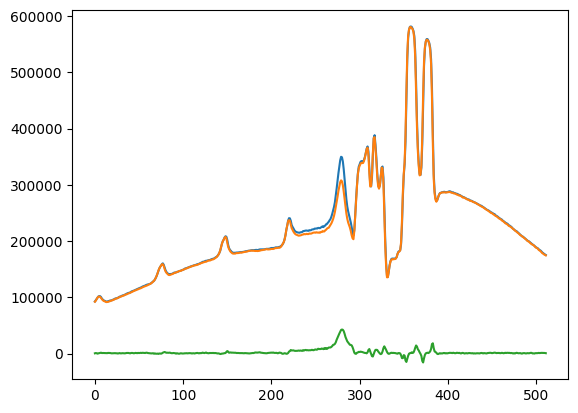

In [4]:
frame_profile = np.sum(scan, axis=2)
plt.plot(frame_profile[4001])
plt.plot(frame_profile[4000])
plt.plot(frame_profile[4001]-frame_profile[4000])
print(np.argmax(frame_profile[4001]-frame_profile[4000]))

279.0 279 4482
(array([118, 122, 127, 129, 131, 135, 147, 149, 151, 153, 154, 156, 157,
       160, 162, 163, 164, 165, 167, 168, 169, 171, 233, 238, 244, 245,
       248, 249, 250, 253, 254, 255, 256, 257, 258, 260, 261, 262, 263,
       264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276,
       277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289,
       290, 291, 310, 311, 312, 313, 315, 316, 327, 328, 329, 333, 349,
       350, 351, 352, 353, 364, 365, 371, 372, 380, 381, 382, 383, 384,
       385, 386, 387, 388, 389, 390, 391, 392, 395, 396, 397, 398, 400,
       401, 402, 404, 405, 406, 410, 442, 447, 448, 449, 451, 455, 461,
       464, 466, 469, 470, 473, 475, 477, 481]), array([   1,    2,    1,    2,    1,    1,    1,    1,    2,    2,    1,
          2,    1,    1,    1,    1,    2,    1,    1,    1,    1,    1,
          1,    1,    1,    2,    1,    1,    1,    1,    1,    3,    1,
          1,    2,    1,    1,    1,    6,    1,    4,    5,   18,  

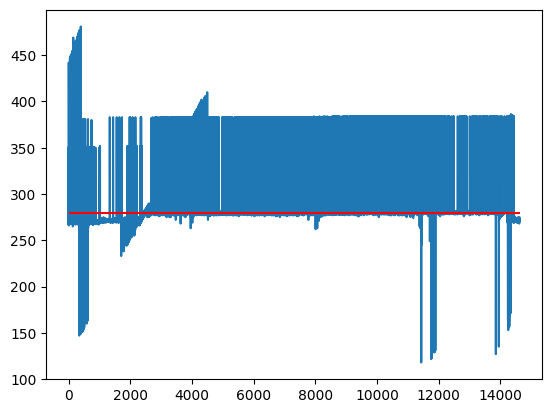

In [5]:
test = np.argmax(np.abs(frame_profile[1:]-frame_profile[:-1]), axis=1)
test_2 = np.unique(test, return_counts=True)
print(np.median(test), test_2[0][np.argmax(test_2[1])], np.max(test_2[1]))
print(test_2)
plt.plot(test)
plt.hlines(280, 0, scan.shape[0], "r")

6 2078 (14628, 512, 640) int16


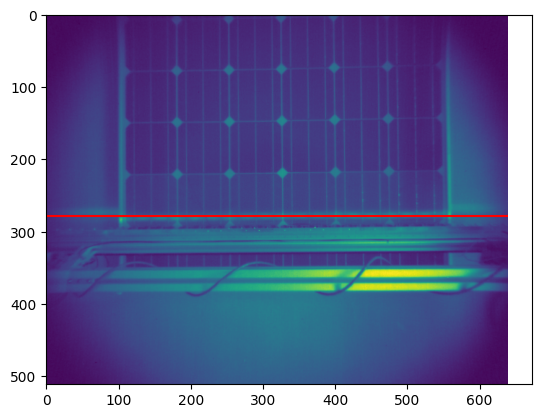

In [6]:
print(np.min(scan), np.max(scan), scan.shape, scan.dtype)
plt.imshow(scan[4002])
plt.hlines(279, 0, 640, "r")

In [7]:
scan_profile = frame_profile[:,279]

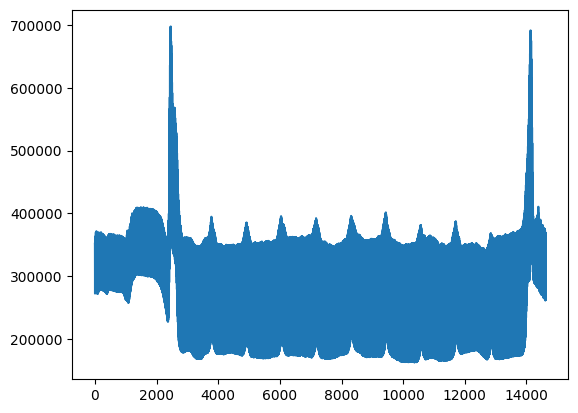

In [8]:
plt.plot(scan_profile)

2460 14133


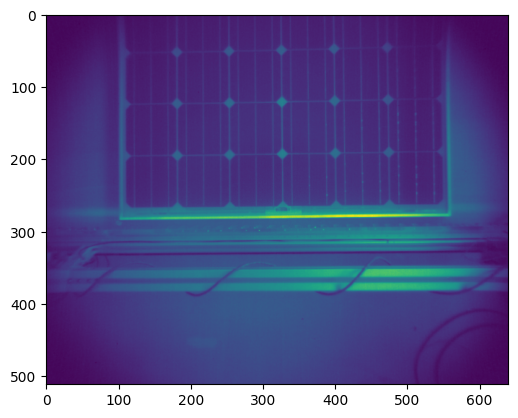

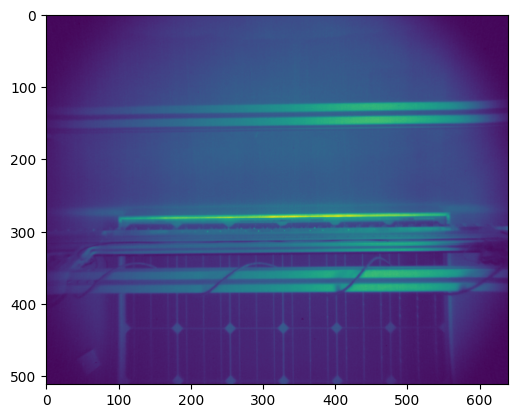

In [9]:
peaks, properties = scipy.signal.find_peaks(scan_profile, prominence=0, wlen=1000)
sorted_index = np.argsort(properties["prominences"])
peak_1 = peaks[sorted_index[-1]]
peak_2 = peaks[sorted_index[-2]]
print(peak_1, peak_2)
module_start = min(peak_1, peak_2)
module_end = max(peak_1, peak_2)
plt.imshow(scan[module_start])
plt.show()
plt.imshow(scan[module_end])
plt.show()

In [10]:
# #scipy envelope??
# #low pass filter or something to detect the large peaks then remove start and end of module for further analysis of the scan
#
# coffs = scipy.signal.butter(2, 1/60, output="sos", btype="lowpass")
# print(coffs)
# low_pass = scipy.signal.sosfilt(coffs, scan_profile)
# plt.plot(low_pass)
#
# peaks, properties = scipy.signal.find_peaks(low_pass, width=0, height=0)
# #plt.plot(peaks, scan_profile[peaks], ".")
# #print(properties["peak_heights"])
# sorted_index = np.argsort(properties["peak_heights"])
# module_start = min(peaks[sorted_index[-1]], peaks[sorted_index[-2]])
# module_end = max(peaks[sorted_index[-2]], peaks[sorted_index[-2]])
# #test_width = int(properties["widths"][sorted_index[-1]])
# print(module_start, module_end)
# plt.vlines((module_start, module_end), 0, np.max(low_pass), "r")
# width_end = properties["widths"][sorted_index[-1]]
# width_start = properties["widths"][sorted_index[-2]]
# print(width_start, width_end)
# plt.vlines((module_start+width_start, module_end-width_end), 0, np.max(low_pass), "g")
#
# plt.imshow(scan[int(module_start+width_start)])
# plt.show()
# plt.imshow(scan[int(module_end-width_start)+2])

[0.         0.00333425 0.0066685  ... 0.00338262 0.00671687 0.01005112]


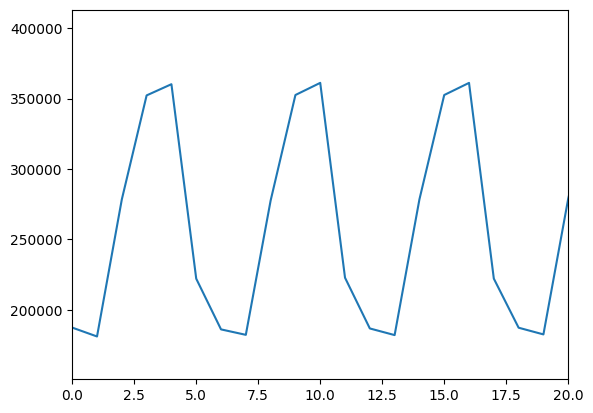

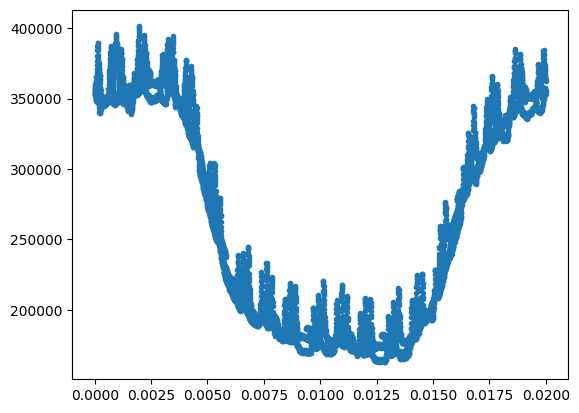

In [11]:
f_m = 50
#f_s = 300
f_s = 299.917668
#print(1/f_m, 6/f_s)
times = (np.arange(scan_profile.shape[0])/f_s) % (1/f_m)
print(times)
sorted_time = np.argsort(times)
trim_start = module_start+500
trim_end = module_end-500
trimmed_profile = scan_profile[trim_start:trim_end]
#plt.plot(trimmed_profile)
#plt.hlines(np.mean(trimmed_profile), 0, 10000, "r")
#binary = np.zeros_like(trimmed_profile)
#binary[trimmed_profile>np.median(trimmed_profile)] = 1
plt.plot(trimmed_profile)
plt.xlim(0, 20)
plt.show()
#to = 18
plt.plot(times[trim_start:trim_end], scan_profile[trim_start:trim_end], ".")

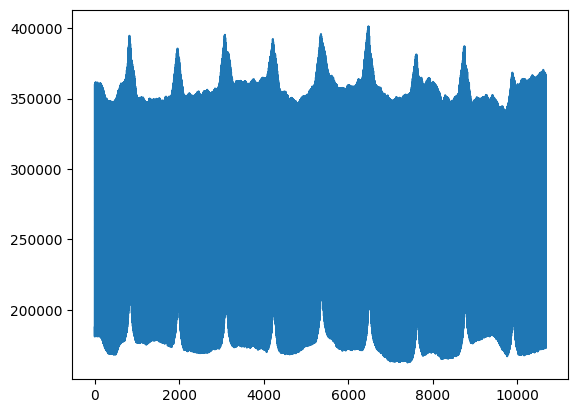

In [13]:
plt.plot(trimmed_profile)

[  14   24   28   33   35   37   42   46   49   53   56   62   64   66
   69   74   77   79   84   86   88   92   94   99  101  103  105  110
  113  115  118  122  124  126  128  130  132  134  138  142  150  157
  160  162  168  171  173  176  181  184  186  189  191  195  198  200
  202  204  207  209  213  215  218  221  224  228  230  234  236  238
  240  242  244  247  251  253  257  261  264  266  271  273  276  280
  282  284  287  289  291  296  298  300  302  304  307  309  313  315
  317  319  327  349  357  361  370  380  382  388  392  401  403  406
  408  413  415  420  422  426  428  430  433  436  438  440  443  445
  449  453  455  457  459  463  467  470  473  476  479  482  486  488
  490  493  495  497  499  503  506  512  514  517  521  523  526  528
  530  532  534  538  543  545  555  560  564  569  574  577  579  581
  588  590  592  594  597  602  604  608  610  615  622  626  630  632
  637  641  643  647  652  654  657  661  664  668  671  676  678  683
  685 

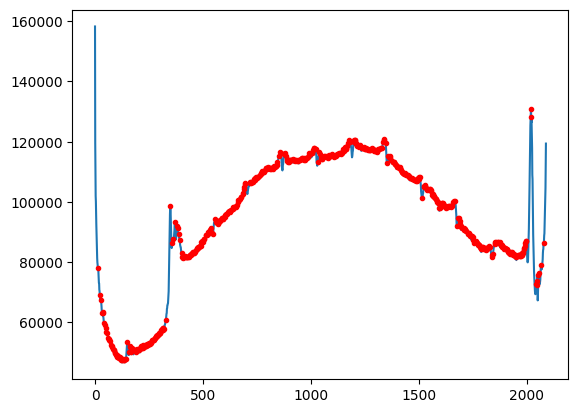

In [26]:
bp_in = (int(50*len(scan_profile)/f_s), None)
scan_env, scan_res = scipy.signal.envelope(scan_profile, bp_in, n_out = int(len(scan_profile)/7))
#plt.plot(scan_profile[trim_start:trim_start+12])
plt.plot(scan_env)
peaks_test, _ = scipy.signal.find_peaks(scan_env)
print(peaks_test)
plt.plot(peaks_test, scan_env[peaks_test], ".r")

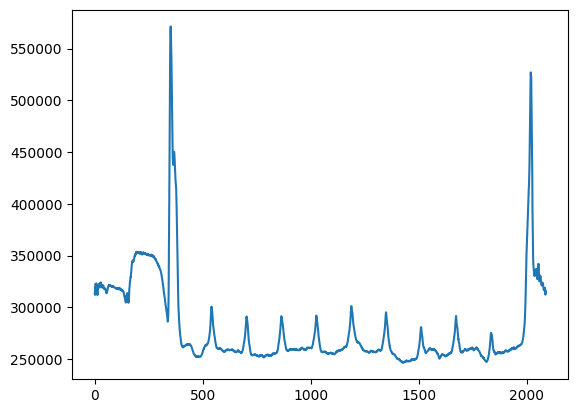

In [27]:
#plt.plot(scan_env)
plt.plot(scan_res)

In [75]:
line_profiles = scan[:, 279, :]
line_env, line_res = scipy.signal.envelope(line_profiles, bp_in, n_out = int(0.3*len(line_profiles)/(int(f_s/f_m))), axis=0)

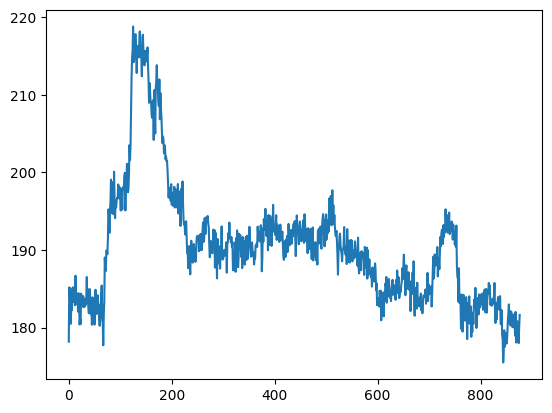

In [76]:
plt.plot(line_res[:,0])

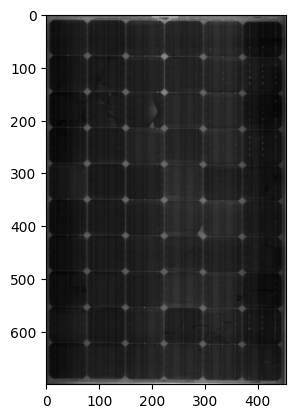

0 255


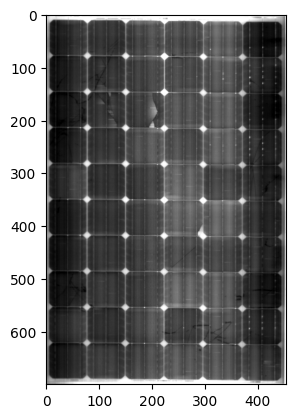

In [147]:
#Vertical
v_profile = line_res.sum(axis=1)
plt.plot(v_profile)
v_peaks, v_peaks_prop = scipy.signal.find_peaks(v_profile, distance=10, prominence=10000, height=0)
#print(res_peaks_prop)
#plt.plot(v_peaks, v_profile[v_peaks], ".r")
#plt.show()
v_peaks_sort = np.argsort(v_peaks_prop["prominences"])
v_mod_start = min(v_peaks[v_peaks_sort[-1]], v_peaks[v_peaks_sort[-2]])
v_mod_end = max(v_peaks[v_peaks_sort[-1]], v_peaks[v_peaks_sort[-2]])


#Horizontal
h_profile = line_res.sum(axis=0)
plt.plot(h_profile)
h_peaks, h_peaks_prop = scipy.signal.find_peaks(h_profile, distance=10, prominence=100000, height=0)
#plt.plot(h_peaks, h_profile[h_peaks], ".r")
#plt.show()
h_mod_start = h_peaks[0]
h_mod_end = h_peaks[-1]

#Final
module = line_res[v_mod_start:v_mod_end, h_mod_start:h_mod_end]
plt.imshow(module, cmap="gray")
plt.show()

#module_process = np.uint16(((module-module.min())/(module.max()-module.min()))*2**16)
module_process = ingaas_processing.lin_stretch_img(module, 0.2, 98)
print(module_process.min(), module_process.max())
plt.imshow(module_process, cmap="gray")
plt.show()

{'peak_heights': array([517741.15873667, 504286.51107465, 516368.0434099 , 564237.5068362 ,
       539353.08148756, 643825.49665026]), 'prominences': array([200412.54600766, 120938.64773038, 120615.67815149, 242820.84386109,
       122899.66721356, 452653.64567952]), 'left_bases': array([  0, 125, 125,   0, 366,   0]), 'right_bases': array([125, 197, 270, 534, 534, 639])}
104 558


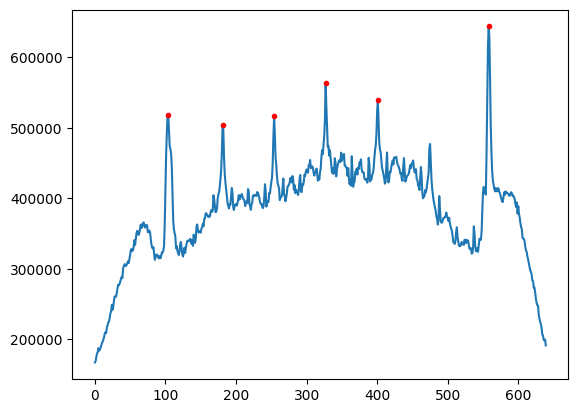

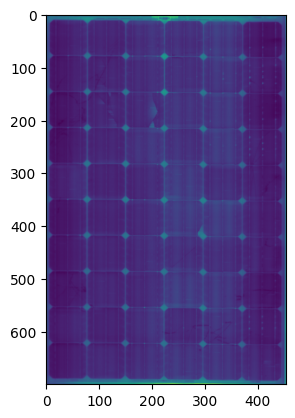